# Probability Distributions I
# Discrete Distributions

This article is part of a series:
- Probability Distributions I - Discrete Distributions
- Probability Distributions II - Continuous Distributions I
- Probability distributions III - Continuous Distributions II

# Outline
- Random Variables
- Bernoulli
- Binomial
- Multinomial
- Poisson
- Negative Binomial
- Geometric
- Hypergeometric

# Random Variables

Before we perform an experiment, the sample outcome is not yet realized, but we can calculate the probability that a random variable $Y$ will take on a range of values. A random variable (RV) is a function mapping the sample space $S$ to the real line $\mathbb{R}$, or a multivariate space, where it can take on one of many possible values from the state space, and assigns probabilities to each of the outcomes.

Discrete random variables are valued in a finite set, or intervals of real numbers, and the probabilities summarized by a probability mass function (PMF). Continuous probability distributions have an infinite number of points along an unbroken function, and the probabilities are summarized by a probability density function (PDF). Most distributions have a cumulative distribution function (CDF), expressing the accumulated sum of probability up to each point, and all have defined 'moments' which include the expected value $E[Y]$ (the mean) and variance $\text{Var}[Y]$ (with standard deviation equal to $\sqrt{\text{Var}[Y]})$.

Prominent sources include https://distribution-explorer.github.io/ (which details the parameterizations used in popular software) for distribution functions, and the <a href="https://www.pymc.io/welcome.html">PyMC user documents</a> for visuals.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as st
import arviz as az
plt.style.use('arviz-darkgrid')
plt.rcParams['figure.figsize'] = (6,4)

# Bernoulli

Perhaps the most intuitive of random variables, a Bernoulli RV represents a single-trial, experiment, with a binary outcome of success ($1$) having probability $p$, or failure ($0$) having probability $q=1-p$.

<u><i>PMF:</i></u>

$f(y;p) = \left\{ \begin{array}{ccc} 1-\theta & & y = 0 \\[0.5em] p & & y = 1. \end{array} \right.$

<u><i>Expected Value:</i></u> $p$

<u><i>Variance:</i></u>: $pq$

<u><i>Conjugate Prior:</i></u>

The conjugate prior of the Bernoulli likelihood is the Beta distribution.

- Conjugate Prior: $p \sim Beta(\alpha, \beta)$

- Likelihood: $Y \sim Bern(p)$

- Posterior: $P(p;Y) \sim Beta(\alpha + y, \beta + 1 - y))$

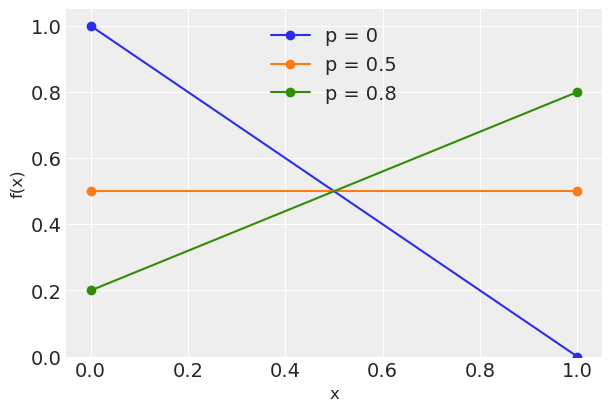

In [2]:
x = [0, 1]
for p in [0, 0.5, 0.8]:
    pmf = st.bernoulli.pmf(x, p)
    plt.plot(x, pmf, '-o', label='p = {}'.format(p))
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.ylim(0)
plt.legend(loc=9)
plt.show()

# Binomial

The Binomial distribution is a generalization of the Bernoulli, from one trial to multiple trials. It represents the likelihood of the number of successes $k$ in $n$ Bernoulli trials of success probability $p$.

<u><i>PMF:</i></u>

$P(Y = k) = \binom{n}{k} p^k q^{n-k}, ~~k \in \{0,1,2,\ldots,n\}$

<u><i>CDF:</i></u>

$F(k;n,p) = I_{1-p}(n - k, k + 1)$

where I_{1-p} is a regularized incomplete beta function,

$I_x(a, b) = \frac{B(x; a, b)}{B(a, b)} = \frac{\int_0^x\mathrm{d}t\,t^{a-1} (1-t)^{b-1}}{\int_0^1\mathrm{d}t\,t^{x-1} (1-t)^{y-1}}.$

<u><i>Expected Value:</i></u> $np$

<u><i>Variance:</i></u> $np(1-p)$

<u><i>Derivation:</i></u>

First, we need to determine the number of ways to arrange $k$ successes in $n$ trials. This is given by the binomial coefficient.

$\binom{n}{k} = \frac{n!}{k!(n-k)!}$

For a specific sequence of $k$ successes and $n-k$ failures, the probability is given by multiplying the probabilities of each trial outcome. Since the trials are independent, we have:

$p^k (1-p)^{n-k}$

Putting it together: the total probability of getting exactly $k$ successes in $n$ trials is the product of the number of ways to arrange $k$ successes and the probability of any specific arrangement of $k$ successes and $n-k$ failures.

$P(Y = k) = \binom{n}{k} p^k q^{n-k}$

<u><i>Conjugate Prior</i></u>:

The conjugate prior of the Binomial likelihood is the Beta distribution.

- Conjugate Prior: $p \sim Beta(\alpha, \beta)$

- Likelihood: $Y \sim Binomial(n, p)$

- Posterior: $Beta(p; Y) \sim Beta(\alpha + y, \beta + n - y)$

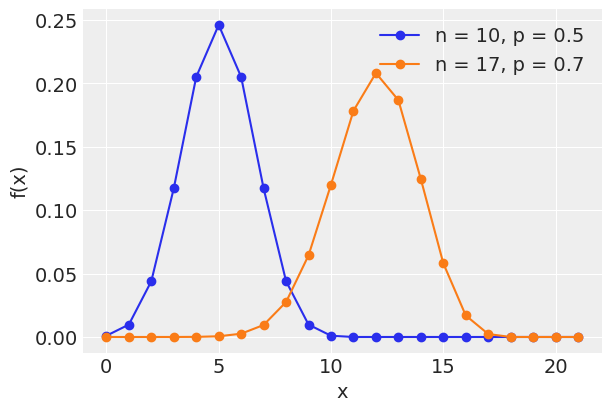

In [3]:
x = np.arange(0, 22)
ns = [10, 17]
ps = [0.5, 0.7]
for n, p in zip(ns, ps):
    pmf = st.binom.pmf(x, n, p)
    plt.plot(x, pmf, '-o', label='n = {}, p = {}'.format(n, p))
plt.xlabel('x', fontsize=14)
plt.ylabel('f(x)', fontsize=14)
plt.legend(loc=1)
plt.show()

# Multinomial

The Multinomial distribution is a multivariate distribution that generalizes the Binomial to more than two categories of outcome (the marginals of the Multinomial are Binomial). Each of $n$ objects is independently placed into one of $k$ categories, each with probability $p_k$.

<u><i>PMF:</i></u>

$P(\mathbf{y};\boldsymbol{\mathbf{p}}, n) = \frac{n!}{y_1!\,y_2! \cdots y_K!}\,p_1^{y_1}\,p_2^{y_2} \cdots p_K^{y_K}$

<u><i>Expected Value:</i></u> $np_i, i = 1, 2, \ldots, k$

<u><i>Variance:</i></u> $np_i(1-p_i), i = 1, 2, \ldots, k$

<u><i>Derivation:</i></u>

If $n_1, \ldots, n_k$ do add up to $n$, then any particular way of putting $n_1$ objects into category 1, $n_2$ into category 2, etc., has probability $p_1^{n_1}, p_2^{n_2}, \ldots, p_k^{n_k}$, and there are $\frac{n!}{n_1! n_2! \ldots n_k!}$ ways to do this.

<u><i>Conjugate Prior:</i></u>

The conjugate prior of the Multinomial likelihood is the Dirichlet distribution.

- Conjugate Prior: $\mathbf{p} \sim Dirichlet(\alpha_1, \ldots, \alpha_k)$

- Likelihood: $Y \sim Multinomial(n, \mathbf{p})$

- Posterior: $P(\mathbf{p}; Y) \sim Dirichlet(\alpha_1 + y_1, \alpha_2 + y_2, \ldots, \alpha_k + n_k)$

# Poisson

The Poisson is defined as a limiting case of the Binomial, as $n \rightarrow \infty$ and $p \rightarrow 0$. It is a model for the frequency $k$ of rare events, with data defined as counts, and expresses the probability of a given number of events occurring in a fixed interval of time or space, in which events occur with a constant mean rate, and independently of the time since the last event. A constraint is that the mean of the data is expected to be (at least approximately) equal to the variance.

<u><i>PMF:</i></u>

$P(Y=k) = \frac{e^{-\lambda}\lambda^k}{k!}$

<u><i>Expected Value:</i></u> $\lambda$

<u><i>Variance:</i></u> $\lambda$

<u><i>CDF:</i></u>

$F(n;\lambda) = \frac{\Gamma(n + 1, \lambda)}{n!},$

where $\Gamma(n + 1, \lambda)$ is the upper incomplete Gamma function, 

$\Gamma(x, y) = \int_y^\infty \mathrm{d}t \, t^{x-1}\mathrm{e}^{-t}.$

<u><i>Derivation:</i></u>

To derive the Poisson, we consider the limiting process as $n \rightarrow \infty$ and $p \rightarrow 0$. The product $np$ is represented by $\lambda$, the average number of successes in $n$ trials.

For large $n$, using the approximation $\binom{n}{k} \approx \frac{n^k}{k!}$, we have:

$\binom{n}{k}p^k (1-p)^{n-k} \approx \frac{n^k}{k!}p^k (1-p)^{n-k}$

Letting $p = \frac{\lambda}{n}$ and substituting $p$ into the expression:

- $P(X=k) \approx \frac{n^k}{k!} \left( \frac{\lambda}{n} \right)^k \left( 1 - \frac{\lambda}{n} \right)^{n-k}$

- $P(X=k) \approx \frac{n^k}{k!} \left( \frac{\lambda^k}{n^k} \right) \left( 1 - \frac{\lambda}{n} \right)^{n-k}$

- $P(X=k) \approx \frac{n^k}{k!} \left( 1 - \frac{\lambda}{n} \right)^n \left( 1 - \frac{\lambda}{n} \right)^{-k}$

As $n \rightarrow \infty$, the term $\left( 1 - \frac{\lambda}{n} \right)^n$ approaches $e^{- \lambda}$ and $\left( 1 - \frac{\lambda}{n} \right)^{-k} \rightarrow 1$. Combining the results, we get:

- $P(Y=k) = \frac{e^{-\lambda}\lambda^k}{k!}$

<u><i>Conjugate Prior:</i></u>

The conjugate prior of the Poisson likelihood is the Gamma distribution.

- Conjugate Prior: $\lambda \sim(\alpha, \beta)$</p>

- Likelihood: $Y \sim Poisson(\lambda)$</p>

- Posterior: $P(\lambda ; Y) \sim Gamma(a + \sum y_i, \beta + 1)$</p>

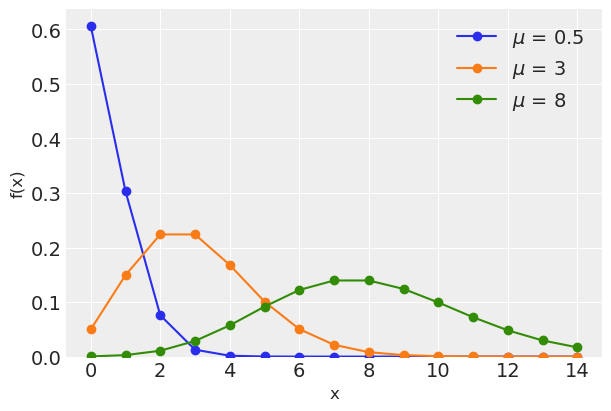

In [4]:
x = np.arange(0, 15)
for m in [0.5, 3, 8]:
    pmf = st.poisson.pmf(x, m)
    plt.plot(x, pmf, '-o', label='$\mu$ = {}'.format(m))
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.ylim(0)
plt.legend(loc=1)
plt.show()

# Negative Binomial

The assumption of the Poisson, that mean equals variance, can be too restrictive when dealing with real-world data. The Negative Binomial has several parameterizations, one of which is based upon a mean $\mu$ and dispersion parameter $\phi$. In this case, $1/\phi$ is the rate of overdispersion compared to a variance that equals the mean, and therefore, the Poisson is a limiting case of the Negative Binomial where $\phi \rightarrow \infty$. The story of the Negative Binomial is that it describes the number of independent Bernoulli trials that lead to failure before a certain number of successes.

<u><i>PMF, Parameterization 1:</i></u>

$f(y;\alpha,\beta) = \begin{pmatrix}
y+\alpha-1 \\
\alpha-1
\end{pmatrix}
\left(\frac{\beta}{1+\beta}\right)^\alpha \left(\frac{1}{1+\beta}\right)^y.$

$\alpha$ is the desired number of successes, and the probability of each Bernoulli trial is given by $\beta/(1+\beta)$. Generally speaking, $\alpha$ does not need to be an integer, so we may write the PDF as:

$f(y;\alpha,\beta) = \frac{\Gamma(y+\alpha)}{\Gamma(\alpha) \, y!}\,\left(\frac{\beta}{1+\beta}\right)^\alpha \left(\frac{1}{1+\beta}\right)^y.$

<u><i>Expected Value:</i></u> $\displaystyle{\frac{\alpha}{\beta}}$

<u><i>Variance:</i></u> $\displaystyle{\frac{\alpha(1+\beta)}{\beta^2}}$

</br>
<u><i>PMF, Parameterization 2:</i></u>

$f(y;\mu,\phi) = \frac{\Gamma(y+\phi)}{\Gamma(\phi) \, y!}\,\left(\frac{\phi}{\mu  +\phi}\right)^\phi\left(\frac{\mu}{\mu+\phi}\right)^y.$

<u><i>Expected Value:</i></u> $\mu$

<u><i>Variance:</i></u> $\displaystyle{\mu\left(1 + \frac{\mu}{\phi}\right)}$

</br>
<u><i>PMF, Parameterization 3:</i></u>

The following version is used in Scipy and Numpy.

$f(y;n, p) = \frac{\Gamma(y+n)}{\Gamma(n) \, y!}\,p^n \left(1-p\right)^y.$

<u><i>Expected Value:</i></u> $\displaystyle{n\,\frac{1-p}{p}}$

<u><i>Variance:</i></u> $\displaystyle{n\,\frac{1-p}{p^2}}$

</br>
<u><i>CDF:</i></u>

Evaluated an non-negative integers n:

$F(n; N, \alpha, \beta) = I_{\beta/(1+\beta)}(\alpha, n + 1),$

where $I_x(a, b)$ is the regularized incomplete beta function,

$I_x(a, b) = \frac{1}{B(a, b)}\,\int_0^x \mathrm{d}y\,y^{a-1}(1-y)^{b-1}$

<u><i>Conjugate Prior:</i></u>

The conjugate prior the success probability $p$ is the Beta distribution.

- Conjugate Prior: $p \sim Beta(\alpha, \beta)$

- Likelihood: $P(y; \alpha, \beta) \propto (1-p)^{\alpha} p^y$

- Posterior: $P(p; Y) \sim Beta(\alpha+y, \beta+\alpha)$

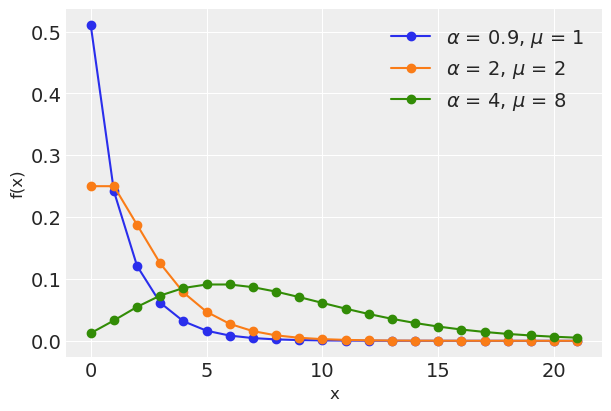

In [5]:
from scipy import special

def NegBinom(a, m, x):
    pmf = special.binom(x + a - 1, x) * (a / (m + a))**a * (m / (m + a))**x
    return pmf

x = np.arange(0, 22)
alphas = [0.9, 2, 4]
mus = [1, 2, 8]
for a, m in zip(alphas, mus):
    pmf = NegBinom(a, m, x)
    plt.plot(x, pmf, '-o', label=r'$\alpha$ = {}, $\mu$ = {}'.format(a, m))
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.legend(loc=1)
plt.show()

# Geometric

The Geometric distribution is a special case of the Negative Binomial where $\phi=1$. In other words, it models the number of trials until the first success.

<u><i>PMF:</i></u>

$f(y;\theta) = (1-\theta)^y \, \theta.$

<u><i>Expected Value:</i></u> $\displaystyle{\frac{1-\theta}{\theta}}$

<u><i>Variance:</i></u> $\displaystyle{\frac{1-\theta}{\theta^2}}$

<u><i>CDF:</i></u>

$F(y;\theta) = 1 - (1 - \theta)^{y+1}.$

<u><i>Conjugate Prior:</i></u>

The conjugate prior for the Geometric likelihood is the Beta distribution.

- Conjugate Prior: $\theta \sim Beta(\alpha, \beta)$</p>

- Likelihood: $Y \sim Geom(\theta)$</p>

- Posterior: $P(\theta; Y) \sim Beta(\alpha + 1, \beta + x)$</p>

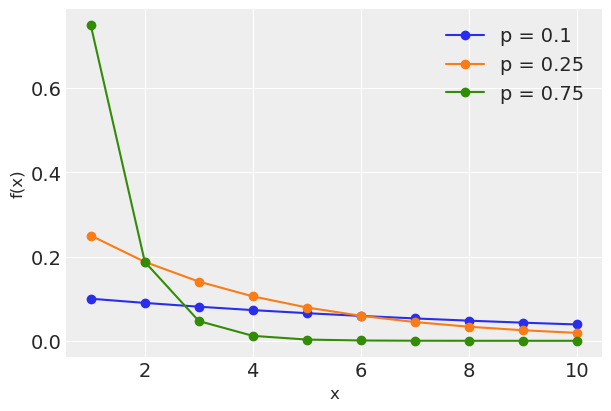

In [3]:
x = np.arange(1, 11)
for p in [0.1, 0.25, 0.75]:
    pmf = st.geom.pmf(x, p)
    plt.plot(x, pmf, '-o', label='p = {}'.format(p))
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.legend(loc=1)
plt.show()

# Hypergeometric

The Hypergeometric distribution is what the Binomial distribution would be if sampling were done without replacement. It measures the probability of $k$ successes in $n$ trials.

Consider an urn with $a$ white balls and $b$ black balls. Draw $N$ balls without replacement. The number of white balls drawn is Hypergeometrically distributed.

<u><i>PMF:</i></u>

$P(X = k) = \frac{\binom{K}{k}\binom{N-k}{n-k}}{\binom{N}{n}}$</h2>

<ul>
    <li>$N$ is the population size</li>
    <li>$K$ is the number of success states in the population</li>
    <li>$n$ is the number of trials/draws</li>
    <li>$k$ is the number of observed successes</li>
</ul>

<u><i>Expected Value:</i></u> $\mu = \frac{nK}{N}$</h2>

<u><i>Variance:</i></u> $\frac{N-n}{N-1} ~n \frac{\mu}{n} ~\left( 1 - \frac{\mu}{n} \right)$</h2>

<u><i>Derivation:</i></u>

- The number of ways to choose $k$ successes from $K$ successes is given by $\binom{K}{k}$.

- The number of ways to choose $n-k$ failures from $N-k$ failures is given by $\binom{N-K}{n-k}$.

- The number of ways to choose $n$ items from $N$ items is given by $\binom{N}{n}$.

Putting it together, the porbability of obtaining exactly k successes in the sample is the ratio of the number of favorable outcomes to the total number of possible outcomes.

$P(X = k) = \frac{\binom{K}{k}\binom{N-k}{n-k}}{\binom{N}{n}}$

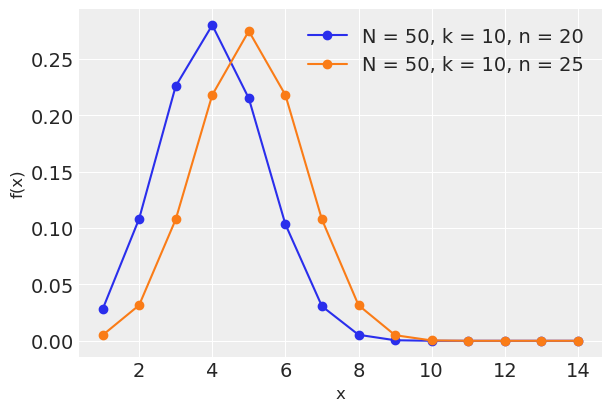

In [4]:
x = np.arange(1, 15)
N = 50
k = 10
for n in [20, 25]:
    pmf = st.hypergeom.pmf(x, N, k, n)
    plt.plot(x, pmf, '-o', label='N = {}, k = {}, n = {}'.format(N, k, n))
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.legend(loc=1)
plt.show()

# References

- ...
- ...